# Setting Up

In [1]:
import tensorflow as tf
import numpy as np
import json
import os
import random
from pycocotools.coco import COCO # Standard library for parsing COCO JSON

# 1. Reproducibility Guarantee
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Random seeds set to {seed} for reproducibility.")

set_seeds(42)

2026-03-26 16:19:42.259941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774541982.432458      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774541982.481348      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774541982.891253      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774541982.891298      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774541982.891300      24 computation_placer.cc:177] computation placer alr

Random seeds set to 42 for reproducibility.


# Parsing the COCO JSON and Filtering Classes

In [2]:
# 1. Install the official FathomNet Python package
!pip install fathomnet

import os
import requests
from tqdm import tqdm 
from pycocotools.coco import COCO
from fathomnet.api import images as fathomnet_images # Import the official API

# 2. Automatically find your train.json file in the Kaggle inputs
ANNOTATION_FILE = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'train.json':
            ANNOTATION_FILE = os.path.join(dirname, filename)
            break

if ANNOTATION_FILE is None:
    raise FileNotFoundError("Could not find train.json. Make sure FathomNet is attached!")

# 3. Create the folder to save the actual downloaded images
IMAGE_SAVE_DIR = '/kaggle/working/images/'
os.makedirs(IMAGE_SAVE_DIR, exist_ok=True)

# 4. Load the JSON and start downloading via the official API
coco = COCO(ANNOTATION_FILE)

def download_images_officially(coco, num_classes=5, max_images_per_class=400):
    cat_ids = coco.getCatIds()
    cats = coco.loadCats(cat_ids)
    
    # Find the most common classes
    cat_frequencies = {cat['id']: len(coco.getImgIds(catIds=[cat['id']])) for cat in cats}
    top_cat_ids = sorted(cat_frequencies, key=cat_frequencies.get, reverse=True)[:num_classes]
    
    image_paths, labels, bboxes = [], [], []
    class_mapping = {cat_id: idx for idx, cat_id in enumerate(top_cat_ids)}
    
    print(f"Downloading images for {num_classes} classes. Max {max_images_per_class} per class...")
    
    for cat_id in top_cat_ids:
        img_ids = coco.getImgIds(catIds=[cat_id])[:max_images_per_class] 
        
        for img_id in tqdm(img_ids, desc=f"Class ID {cat_id}"):
            img_info = coco.loadImgs(img_id)[0]
            
            # Extract the UUID from the filename
            file_name = img_info['file_name']
            uuid = file_name.split('.')[0] 
            save_path = os.path.join(IMAGE_SAVE_DIR, file_name)
            
            # Download the image if it isn't already saved
            if not os.path.exists(save_path):
                try:
                    # USE THE OFFICIAL API TO FIND THE TRUE IMAGE URL
                    image_record = fathomnet_images.find_by_uuid(uuid)
                    
                    if not image_record or not image_record.url:
                        continue # Skip if the database has no URL for this UUID
                    
                    # Now download the image from the true URL!
                    headers = {'User-Agent': 'Mozilla/5.0'}
                    img_response = requests.get(image_record.url, headers=headers, timeout=15)
                    img_response.raise_for_status()
                    
                    with open(save_path, 'wb') as f:
                        f.write(img_response.content)
                        
                except Exception as e:
                    continue # Skip if link is broken or network times out
            
            # Get the bounding box for cropping later
            ann_ids = coco.getAnnIds(imgIds=img_info['id'], catIds=[cat_id], iscrowd=None)
            if anns := coco.loadAnns(ann_ids):
                image_paths.append(save_path)
                labels.append(class_mapping[cat_id])
                bboxes.append(anns[0]['bbox'])
                
    return image_paths, labels, bboxes, class_mapping

# Run it!
image_paths, labels, bboxes, class_map = download_images_officially(coco)
print(f"\nSuccess! Downloaded {len(image_paths)} images into {IMAGE_SAVE_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 26.0 MB/s eta 0:00:00
loading annotations into memory...
Done (t=5.18s)
creating index...
index created!


Class ID 28: 100%|██████████| 400/400 [13:45<00:00,  2.06s/it]


Success! Downloaded 2000 images into /kaggle/working/images/


# Preprocessing and Augmentation

In [3]:
import os
import tensorflow as tf

print("1. Filtering for valid, clean images...")
clean_paths, clean_labels, clean_bboxes = [], [], []

for path, label, bbox in zip(image_paths, labels, bboxes):
    width, height = bbox[2], bbox[3]
    if os.path.exists(path) and os.path.getsize(path) > 0 and width > 0 and height > 0:
        clean_paths.append(path)
        clean_labels.append(label)
        clean_bboxes.append(bbox)

dataset_size = len(clean_paths)
print(f"Filtered down to {dataset_size} valid images.")

# -------------------------------------------------------------------
BATCH_SIZE = 16 
IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_and_crop(image_path, label, bbox):
    """Reads the image, dynamically clamps the bbox, and crops."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    
    # 1. Get the actual dimensions of the downloaded image
    img_shape = tf.shape(image)
    img_h, img_w = img_shape[0], img_shape[1]
    
    # 2. Extract bounding box variables
    x_min = tf.cast(bbox[0], tf.int32)
    y_min = tf.cast(bbox[1], tf.int32)
    box_w = tf.cast(bbox[2], tf.int32)
    box_h = tf.cast(bbox[3], tf.int32)
    
    # 3. THE FIX: Clamp the coordinates! 
    # Don't let x or y be less than 0
    x_min = tf.maximum(0, x_min)
    y_min = tf.maximum(0, y_min)
    
    # Don't let the width or height push past the edge of the image
    box_w = tf.minimum(box_w, img_w - x_min)
    box_h = tf.minimum(box_h, img_h - y_min)
    
    # Absolute failsafe: if clamping made them 0, force them to 1 pixel
    box_w = tf.maximum(1, box_w)
    box_h = tf.maximum(1, box_h)
    
    # 4. Safe Crop
    image = tf.image.crop_to_bounding_box(
        image, 
        offset_height=y_min, 
        offset_width=x_min, 
        target_height=box_h, 
        target_width=box_w
    )
    
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

# -------------------------------------------------------------------
if dataset_size > 0:
    print("2. Building the dataset pipeline...")
    dataset = tf.data.Dataset.from_tensor_slices((clean_paths, clean_labels, clean_bboxes))
    dataset = dataset.shuffle(buffer_size=dataset_size, seed=42)
    
    train_size = int(0.8 * dataset_size)
    train_dataset = dataset.take(train_size)
    val_dataset = dataset.skip(train_size)
    
    train_dataset = (train_dataset
                     .map(preprocess_and_crop, num_parallel_calls=AUTOTUNE)
                     .map(augment_image, num_parallel_calls=AUTOTUNE)
                     .batch(BATCH_SIZE)
                     .prefetch(AUTOTUNE))
                     
    val_dataset = (val_dataset
                   .map(preprocess_and_crop, num_parallel_calls=AUTOTUNE)
                   .batch(BATCH_SIZE)
                   .prefetch(AUTOTUNE))
    
    print("\nSUCCESS: Dataset built with Out-Of-Bounds protection! 🛡️")
else:
    print("\nERROR: No valid images left!")

1. Filtering for valid, clean images...
Filtered down to 1999 valid images.
2. Building the dataset pipeline...


I0000 00:00:1774545805.144505      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



SUCCESS: Dataset built with Out-Of-Bounds protection! 🛡️


# 4.2 Model A: Convolutional Neural Network from Scratch

##  Written Justifications
**1. Architecture Design (Depth, Width, and Filter Sizes)**
The network is designed with three sequential convolutional blocks 

* Filter Sizes: We use standard 3x3 convolutional kernels. This is efficient while being highly effective at capturing local spatial patterns without missing fine-grained details.

* Depth and Width: The network depth is set to 3 blocks, which is sufficient for mid-level complexity. The width (number of filters) doubles at each block (32 $\rightarrow$ 64 $\rightarrow$ 128). This forces the network to learn simple features (edges, colors) in the early layers and highly complex, abstract features in the deeper layers.

* Activation Functions: The Non-Linear ReLU (Rectified Linear Unit) is used across all convolutional and hidden dense layers because it mitigates the vanishing gradient problem. Softmax is used in the final layer for a multi-class probability distribution.

**2. Regularization Strategy**

* Batch Normalization: Placed immediately after the Convolutional layer and before the ReLU activation. This stabilizes the learning process by normalizing the inputs to the activation function.

* Dropout: A dropout rate of 0.5 is applied in the fully connected classification head. Randomly zeroing out 50% of the neurons during each training step, it prevents the network from relying too heavily on specific pathways.

**3. Optimizer and Learning Rate Schedule**

* Optimizer: We use the Adam optimizer. It combines the advantages of AdaGrad and RMSProp, dynamically computing individual learning rates for different parameters, which is highly effective for noisy imagery.


* Learning Rate Schedule: Instead of a static learning rate, we implement a ReduceLROnPlateau callback.This acts as an empirical schedule: if the validation loss stops improving for 3 consecutive epochs, the learning rate is reduced by a factor of 0.2. This allows the model to take large steps initially and fine-tune its weights as it gets closer to the local minima.

In [4]:
from tensorflow.keras import layers, models, callbacks, optimizers

def build_model_a(num_classes, input_shape=(224, 224, 3)):
    """Builds the CNN from scratch with 3 blocks and a classification head."""
    model = models.Sequential()
    
    # Block 1: Conv -> BatchNorm -> ReLU -> Pool
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Block 2: Conv -> BatchNorm -> ReLU -> Pool
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Block 3: Conv -> BatchNorm -> ReLU -> Pool
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # Fully Connected Classification Head
    model.add(layers.Flatten())
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5)) # Regularization
    
    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    return model

# Setup Callbacks
def get_callbacks(model_name):
    # 1. Save the best model based on validation accuracy
    checkpoint_cb = callbacks.ModelCheckpoint(
        filepath=f'/kaggle/working/{model_name}_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
    
    # 2. Learning rate schedule: Reduce LR if val_loss plateaus
    reduce_lr_cb = callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=3,
        min_delta=0.0001,
        min_lr=1e-6,
        verbose=1
    )
    
    return [checkpoint_cb, reduce_lr_cb]

# Assuming num_classes is defined from your earlier COCO parsing (e.g., 5)
NUM_CLASSES = len(class_map) 
EPOCHS = 15 # Keep it relatively low to test quickly on Kaggle



In [5]:
# ==========================================
# Configuration 1: Standard Learning Rate
# ==========================================
print("Training Configuration 1: LR=0.001")
model_config_1 = build_model_a(num_classes=NUM_CLASSES)
model_config_1.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_config_1.fit(
    train_dataset, # From your section 4.1 pipeline
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=get_callbacks('model_a_config1')
)



Training Configuration 1: LR=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15


I0000 00:00:1774545811.702324      74 service.cc:152] XLA service 0x7fb7cc002320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774545811.702361      74 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774545812.529902      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/100 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2812 - loss: 2.2699 

I0000 00:00:1774545817.410024      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.4484 - loss: 1.4712
Epoch 1: val_accuracy improved from -inf to 0.19000, saving model to /kaggle/working/model_a_config1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 564ms/step - accuracy: 0.4489 - loss: 1.4693 - val_accuracy: 0.1900 - val_loss: 2.7392 - learning_rate: 0.0010
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.5502 - loss: 1.1191
Epoch 2: val_accuracy improved from 0.19000 to 0.20000, saving model to /kaggle/working/model_a_config1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 515ms/step - accuracy: 0.5506 - loss: 1.1183 - val_accuracy: 0.2000 - val_loss: 2.4895 - learning_rate: 0.0010
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6030 - loss: 1.0192
Epoch 3: val_accuracy improved from 0.20000 to 0.22000, saving model to /kaggle/working/model_a_config1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 526ms/step - accuracy: 0.6032 - loss: 1.0185 - val_accuracy: 0.2200 - val_loss: 2.49

In [6]:
# ==========================================
# Configuration 2: Lower Learning Rate 
# ==========================================
print("\nTraining Configuration 2: LR=0.0001")
model_config_2 = build_model_a(num_classes=NUM_CLASSES)
model_config_2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_config_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=get_callbacks('model_a_config2')
)


Training Configuration 2: LR=0.0001
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.5010 - loss: 1.4233
Epoch 1: val_accuracy improved from -inf to 0.17750, saving model to /kaggle/working/model_a_config2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 514ms/step - accuracy: 0.5013 - loss: 1.4216 - val_accuracy: 0.1775 - val_loss: 2.5286 - learning_rate: 1.0000e-04
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6053 - loss: 0.9846
Epoch 2: val_accuracy improved from 0.17750 to 0.19750, saving model to /kaggle/working/model_a_config2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 514ms/step - accuracy: 0.6054 - loss: 0.9843 - val_accuracy: 0.1975 - val_loss: 2.8704 - learning_rate: 1.0000e-04
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.6790 - loss: 0.8362
Epoch 3: val_accuracy improved from 0.19750 to 0.29500, saving model to /kaggle/working/model_a_config2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 528ms/step - accuracy: 0.678

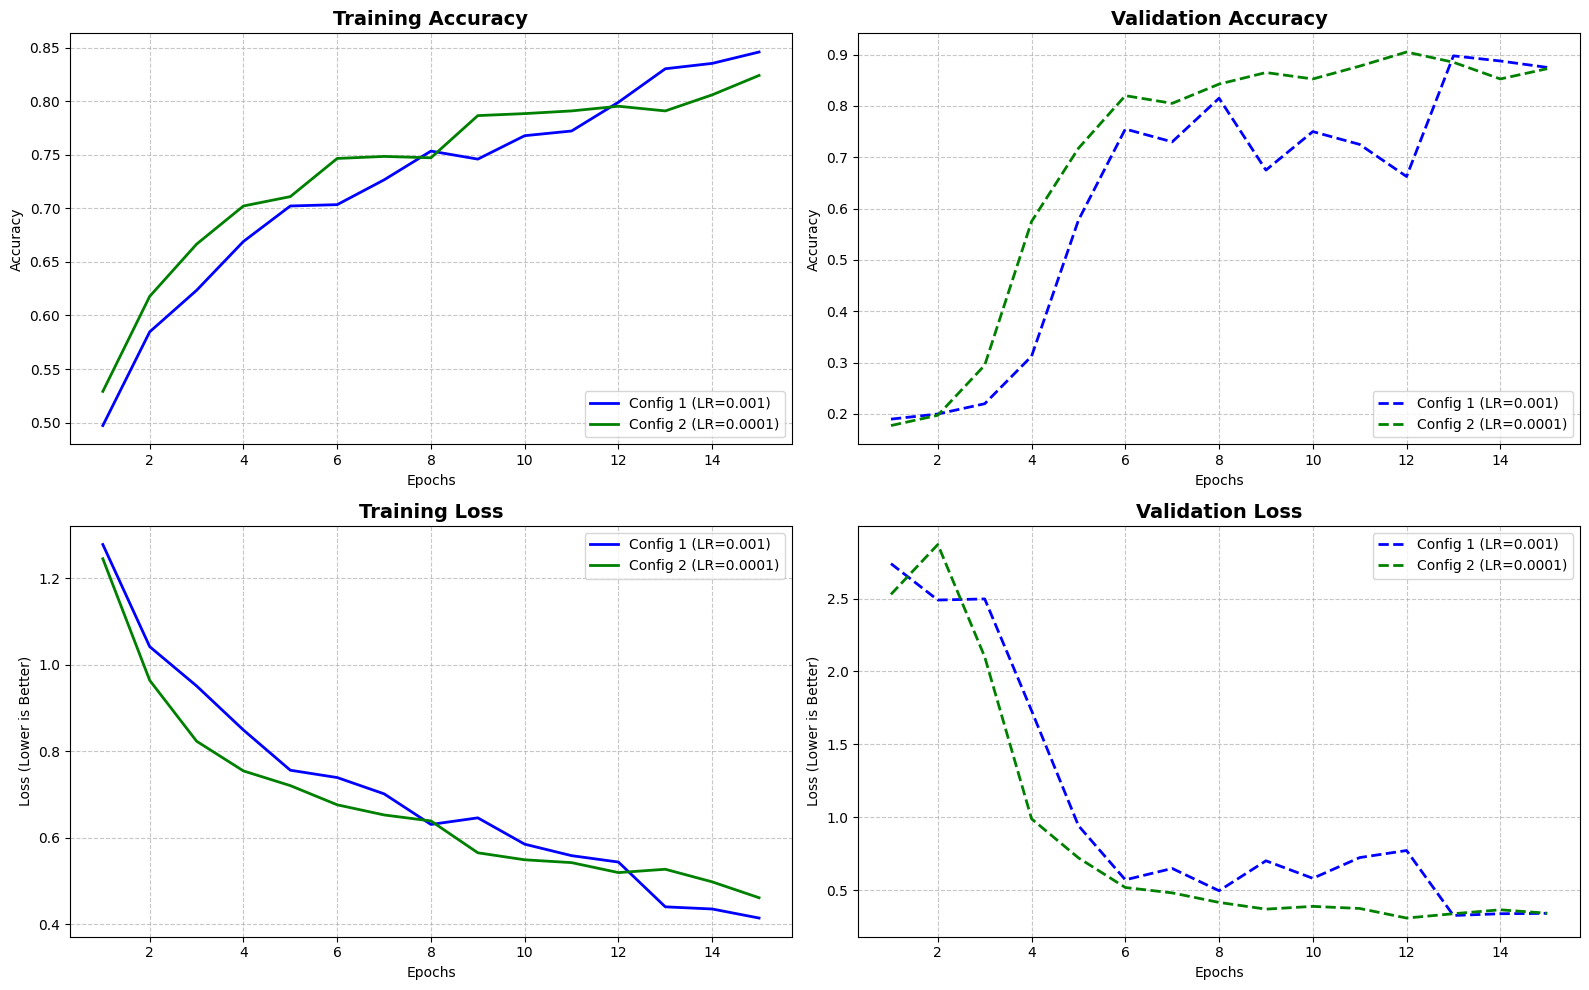

In [7]:
import matplotlib.pyplot as plt

# 1. Extract ALL the data from your history variables
# Configuration 1 (LR = 0.001)
acc_1 = history_1.history['accuracy']
val_acc_1 = history_1.history['val_accuracy']
loss_1 = history_1.history['loss']
val_loss_1 = history_1.history['val_loss']

# Configuration 2 (LR = 0.0001)
acc_2 = history_2.history['accuracy']
val_acc_2 = history_2.history['val_accuracy']
loss_2 = history_2.history['loss']
val_loss_2 = history_2.history['val_loss']

# Get the number of epochs to use for the X-axis
epochs = range(1, len(acc_1) + 1)

# 2. Set up a massive 2x2 plotting area
plt.figure(figsize=(16, 10))

# --- Graph 1: Training Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs, acc_1, 'b-', linewidth=2, label='Config 1 (LR=0.001)')
plt.plot(epochs, acc_2, 'g-', linewidth=2, label='Config 2 (LR=0.0001)')
plt.title('Training Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Graph 2: Validation Accuracy ---
plt.subplot(2, 2, 2)
plt.plot(epochs, val_acc_1, 'b--', linewidth=2, label='Config 1 (LR=0.001)')
plt.plot(epochs, val_acc_2, 'g--', linewidth=2, label='Config 2 (LR=0.0001)')
plt.title('Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Graph 3: Training Loss ---
plt.subplot(2, 2, 3)
plt.plot(epochs, loss_1, 'b-', linewidth=2, label='Config 1 (LR=0.001)')
plt.plot(epochs, loss_2, 'g-', linewidth=2, label='Config 2 (LR=0.0001)')
plt.title('Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (Lower is Better)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Graph 4: Validation Loss ---
plt.subplot(2, 2, 4)
plt.plot(epochs, val_loss_1, 'b--', linewidth=2, label='Config 1 (LR=0.001)')
plt.plot(epochs, val_loss_2, 'g--', linewidth=2, label='Config 2 (LR=0.0001)')
plt.title('Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (Lower is Better)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Display the graphs neatly
plt.tight_layout()
plt.show()

## change bias


In [ ]:
# import tensorflow as tf
from tensorflow.keras import optimizers

# Define our two hyperparameter configurations
BATCH_SIZE_1 = 32
BATCH_SIZE_2 = 64

print(f"--- Preparing Datasets for Batch Sizes {BATCH_SIZE_1} and {BATCH_SIZE_2} ---")

# Unbatch the original datasets and re-batch them to our target sizes
train_ds_config1 = train_dataset.unbatch().batch(BATCH_SIZE_1).prefetch(tf.data.AUTOTUNE)
val_ds_config1 = val_dataset.unbatch().batch(BATCH_SIZE_1).prefetch(tf.data.AUTOTUNE)

train_ds_config2 = train_dataset.unbatch().batch(BATCH_SIZE_2).prefetch(tf.data.AUTOTUNE)
val_ds_config2 = val_dataset.unbatch().batch(BATCH_SIZE_2).prefetch(tf.data.AUTOTUNE)

# ==========================================
# Configuration 1: Batch Size = 32
# ==========================================
print(f"\n🚀 Training Configuration 1: Batch Size = {BATCH_SIZE_1}")
model_config_1 = build_model_a(num_classes=NUM_CLASSES)
model_config_1.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_config_1.fit(
    train_ds_config1, 
    validation_data=val_ds_config1,
    epochs=EPOCHS,
    callbacks=get_callbacks('model_a_bs32')
)



--- Preparing Datasets for Batch Sizes 32 and 64 ---

🚀 Training Configuration 1: Batch Size = 32
Epoch 1/15
     50/Unknown 57s 988ms/step - accuracy: 0.4399 - loss: 1.4347
Epoch 1: val_accuracy improved from -inf to 0.21000, saving model to /kaggle/working/model_a_bs32_best.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4412 - loss: 1.4310 - val_accuracy: 0.2100 - val_loss: 1.9741 - learning_rate: 0.0010
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.5668 - loss: 1.0406
Epoch 2: val_accuracy did not improve from 0.21000
50/50 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5670 - loss: 1.0399 - val_accuracy: 0.2100 - val_loss: 2.7652 - learning_rate: 0.0010
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.6128 - loss: 0.9324
Epoch 3: val_accuracy did not improve from 0.21000
50/50 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6131 - loss: 0.9321 - val_accuracy: 0.1975 - val_loss: 3.0724 - learning_rate: 0.0010
Epoch 4/15
50/50 ━━━━━━━━━

In [ ]:
# ==========================================
# Configuration 2: Batch Size = 64
# ==========================================
print(f"\n🚀 Training Configuration 2: Batch Size = {BATCH_SIZE_2}")
model_config_2 = build_model_a(num_classes=NUM_CLASSES)
model_config_2.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_config_2.fit(
    train_ds_config2, 
    validation_data=val_ds_config2,
    epochs=EPOCHS,
    callbacks=get_callbacks('model_a_bs64')
)


🚀 Training Configuration 2: Batch Size = 64
Epoch 1/15
     25/Unknown 64s 2s/step - accuracy: 0.4097 - loss: 1.6871
Epoch 1: val_accuracy improved from -inf to 0.25750, saving model to /kaggle/working/model_a_bs64_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.4125 - loss: 1.6761 - val_accuracy: 0.2575 - val_loss: 1.6730 - learning_rate: 0.0010
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6167 - loss: 0.9059
Epoch 2: val_accuracy did not improve from 0.25750
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6168 - loss: 0.9062 - val_accuracy: 0.2125 - val_loss: 2.1373 - learning_rate: 0.0010
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6483 - loss: 0.8761
Epoch 3: val_accuracy did not improve from 0.25750
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6490 - loss: 0.8745 - val_accuracy: 0.1825 - val_loss: 2.7011 - learning_rate: 0.0010
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6964 - loss: 0.7584
Epoch

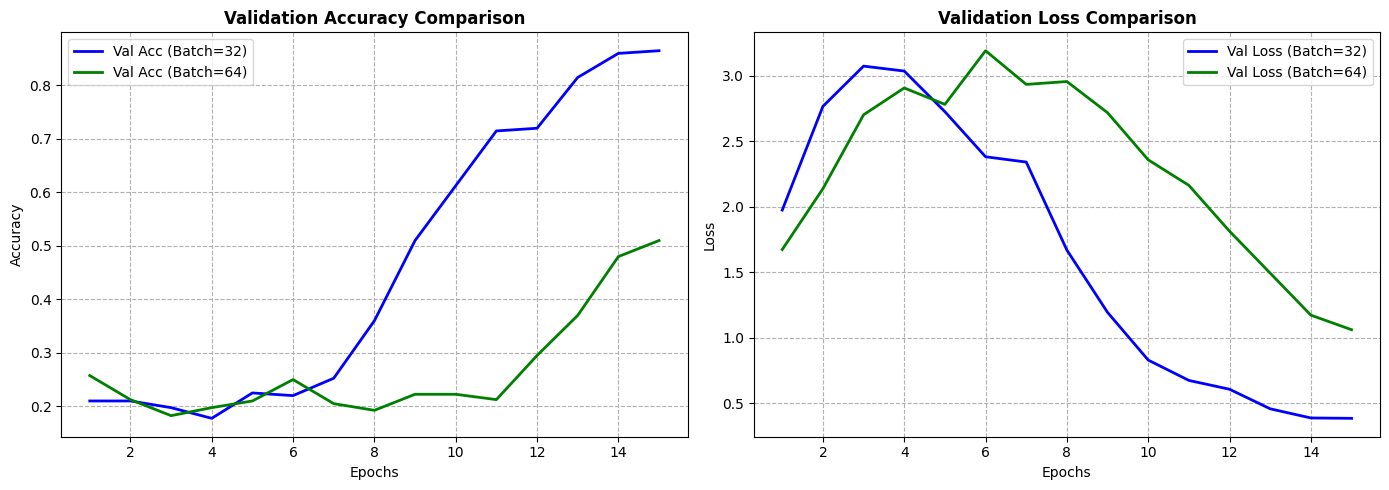

In [ ]:
import matplotlib.pyplot as plt

# Extract data
acc_1, val_acc_1 = history_1.history['accuracy'], history_1.history['val_accuracy']
loss_1, val_loss_1 = history_1.history['loss'], history_1.history['val_loss']

acc_2, val_acc_2 = history_2.history['accuracy'], history_2.history['val_accuracy']
loss_2, val_loss_2 = history_2.history['loss'], history_2.history['val_loss']

epochs = range(1, len(acc_1) + 1)

plt.figure(figsize=(14, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs, val_acc_1, 'b-', linewidth=2, label=f'Val Acc (Batch={BATCH_SIZE_1})')
plt.plot(epochs, val_acc_2, 'g-', linewidth=2, label=f'Val Acc (Batch={BATCH_SIZE_2})')
plt.title('Validation Accuracy Comparison', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--')

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs, val_loss_1, 'b-', linewidth=2, label=f'Val Loss (Batch={BATCH_SIZE_1})')
plt.plot(epochs, val_loss_2, 'g-', linewidth=2, label=f'Val Loss (Batch={BATCH_SIZE_2})')
plt.title('Validation Loss Comparison', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# model 2


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("--- STRATEGY 1: FEATURE EXTRACTION ---")

# 1. Load the pre-trained backbone WITHOUT its original classification head
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# 2. FREEZE the entire backbone so its weights don't change
base_model.trainable = False 

# 3. Build your custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) # Helps prevent overfitting
predictions = Dense(5, activation='softmax')(x) # 5 classes for your dataset

# 4. Combine them into your Model B
model_b = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile and Train
model_b.compile(optimizer=Adam(learning_rate=0.001), 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

history_feature_extraction = model_b.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10, # 10 epochs is usually plenty for feature extraction
    callbacks=get_callbacks('model_b_config1')
)

--- STRATEGY 1: FEATURE EXTRACTION ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.4849 - loss: 1.2459
Epoch 1: val_accuracy improved from -inf to 0.82000, saving model to /kaggle/working/model_b_config1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 601ms/step - accuracy: 0.4864 - loss: 1.2426 - val_accuracy: 0.8200 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8090 - loss: 0.5050
Epoch 2: val_accuracy improved from 0.82000 to 0.89500, saving model to /kaggle/working/model_b_config1_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 531ms/step - accuracy: 0.8091 - loss: 0.5049 - val_accuracy: 0.8950 - val_loss: 0.3344 - learning_rate: 0.0010
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8412 - loss: 0.4450
Epoch 3: val_accuracy did not improve from 0.89500
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 503ms/step - accuracy: 0.8414 - loss: 0.4447 - va

In [9]:
print("--- STRATEGY 2: PARTIAL FINE-TUNING ---")

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Re-freeze the bottom layers, leaving only the top ~20 layers unfrozen
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. RECOMPILE the model (You MUST recompile after changing trainable layers!)
# Use a smaller learning rate so we don't wreck the pre-trained weights
model_b.compile(optimizer=Adam(learning_rate=0.0001), # Notice the smaller LR!
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

# 4. Train again for a few more epochs
history_partial_tune = model_b.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=get_callbacks('model_b_config2')
)

--- STRATEGY 2: PARTIAL FINE-TUNING ---
Epoch 1/10


2026-03-26 17:58:47.407336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:58:47.604531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7654 - loss: 0.6545

2026-03-26 17:59:35.535080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-26 17:59:35.732629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7658 - loss: 0.6531
Epoch 1: val_accuracy improved from -inf to 0.86000, saving model to /kaggle/working/model_b_config2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 624ms/step - accuracy: 0.7663 - loss: 0.6518 - val_accuracy: 0.8600 - val_loss: 0.3672 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8789 - loss: 0.3423
Epoch 2: val_accuracy did not improve from 0.86000
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 521ms/step - accuracy: 0.8789 - loss: 0.3422 - val_accuracy: 0.8100 - val_loss: 0.6590 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8984 - loss: 0.2638
Epoch 3: val_accuracy did not improve from 0.86000
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 502ms/step - accuracy: 0.8983 - loss: 0.2641 - val_accuracy: 0.7050 - val_loss: 1.1730 - learning_rate: 1.0000e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9189 - loss: 0.2331
E

In [10]:
print("--- STRATEGY 3: FULL FINE-TUNING ---")

# 1. Unfreeze absolutely everything
base_model.trainable = True

# 2. Recompile with a VERY low learning rate
model_b.compile(optimizer=Adam(learning_rate=1e-5), # Extremely small LR
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

# 3. Train the whole network end-to-end
history_full_tune = model_b.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=get_callbacks('model_b_config3')
)

--- STRATEGY 3: FULL FINE-TUNING ---
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9354 - loss: 0.1720
Epoch 1: val_accuracy improved from -inf to 0.88750, saving model to /kaggle/working/model_b_config3_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 586ms/step - accuracy: 0.9354 - loss: 0.1719 - val_accuracy: 0.8875 - val_loss: 0.2709 - learning_rate: 1.0000e-05
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9520 - loss: 0.1497
Epoch 2: val_accuracy did not improve from 0.88750
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 497ms/step - accuracy: 0.9520 - loss: 0.1497 - val_accuracy: 0.8800 - val_loss: 0.2564 - learning_rate: 1.0000e-05
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9563 - loss: 0.1423
Epoch 3: val_accuracy improved from 0.88750 to 0.90500, saving model to /kaggle/working/model_b_config3_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 510ms/step - accuracy: 0.9563 - loss: 0.1423 - val_accuracy: 0.9050 - val_loss: 0.2116 - lea

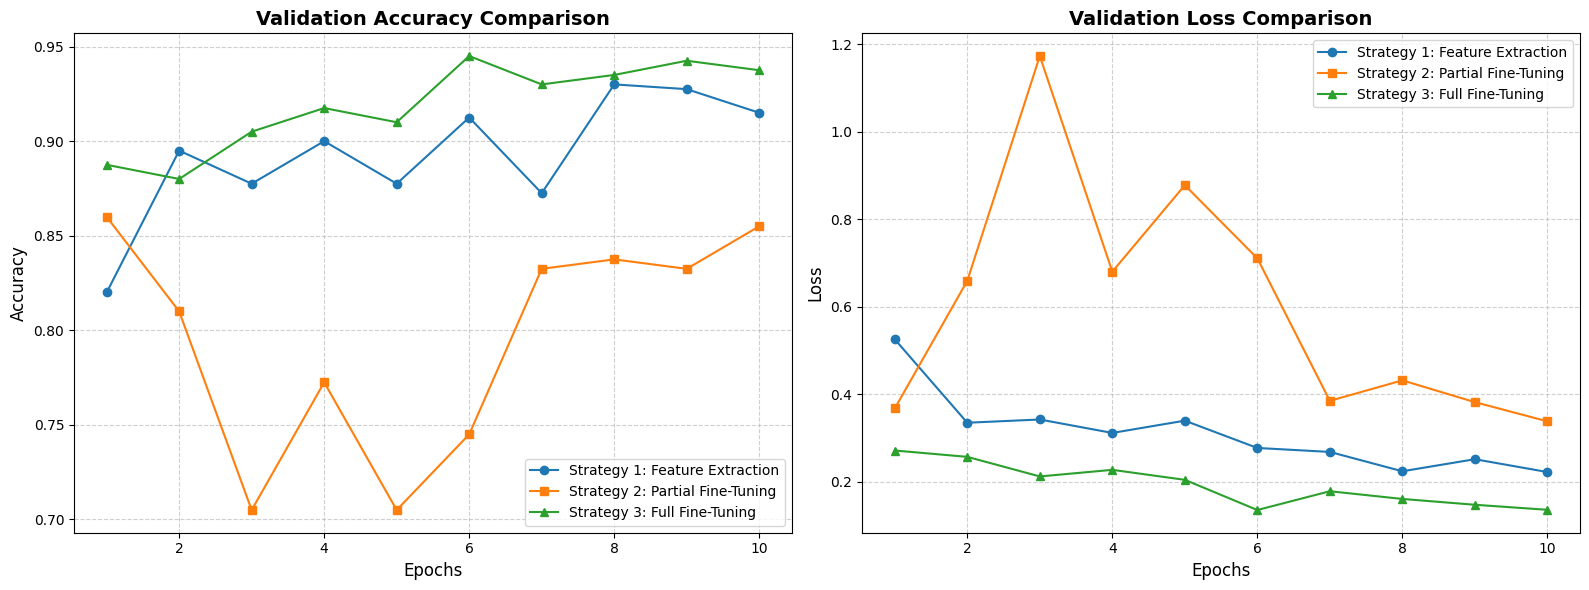

--------------------------------------------------
 FINAL VALIDATION METRICS REPORT 
--------------------------------------------------
Strategy 1 (Feature Extraction) Peak Accuracy : 93.00%
Strategy 2 (Partial Fine-Tuning) Peak Accuracy: 86.00%
Strategy 3 (Full Fine-Tuning) Peak Accuracy   : 94.50%

 THE BEST STRATEGY IS: Full Fine-Tuning with 94.50% Accuracy!


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Gather the validation metrics from your training histories
# (Change the variable names if you used history_1, history_2, history_3 instead)
val_acc_1 = history_feature_extraction.history['val_accuracy']
val_acc_2 = history_partial_tune.history['val_accuracy']
val_acc_3 = history_full_tune.history['val_accuracy']

val_loss_1 = history_feature_extraction.history['val_loss']
val_loss_2 = history_partial_tune.history['val_loss']
val_loss_3 = history_full_tune.history['val_loss']

epochs_range = range(1, len(val_acc_1) + 1)

# 2. Plotting Validation Accuracy & Loss
plt.figure(figsize=(16, 6))

# --- Graph 1: Validation Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, val_acc_1, label='Strategy 1: Feature Extraction', marker='o')
plt.plot(epochs_range, val_acc_2, label='Strategy 2: Partial Fine-Tuning', marker='s')
plt.plot(epochs_range, val_acc_3, label='Strategy 3: Full Fine-Tuning', marker='^')
plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Graph 2: Validation Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_loss_1, label='Strategy 1: Feature Extraction', marker='o')
plt.plot(epochs_range, val_loss_2, label='Strategy 2: Partial Fine-Tuning', marker='s')
plt.plot(epochs_range, val_loss_3, label='Strategy 3: Full Fine-Tuning', marker='^')
plt.title('Validation Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Print the exact maximum validation metrics for your report
print("-" * 50)
print(" FINAL VALIDATION METRICS REPORT ")
print("-" * 50)
print(f"Strategy 1 (Feature Extraction) Peak Accuracy : {max(val_acc_1) * 100:.2f}%")
print(f"Strategy 2 (Partial Fine-Tuning) Peak Accuracy: {max(val_acc_2) * 100:.2f}%")
print(f"Strategy 3 (Full Fine-Tuning) Peak Accuracy   : {max(val_acc_3) * 100:.2f}%\n")

# Find the overall winner
best_accs = [max(val_acc_1), max(val_acc_2), max(val_acc_3)]
strategies = ["Feature Extraction", "Partial Fine-Tuning", "Full Fine-Tuning"]
winner_idx = np.argmax(best_accs)

print(f" THE BEST STRATEGY IS: {strategies[winner_idx]} with {best_accs[winner_idx] * 100:.2f}% Accuracy!")

# OOD

In [12]:
import os
import requests
from tqdm import tqdm
from fathomnet.api import images as fathomnet_images

IMAGE_SAVE_DIR = '/kaggle/working/images/'
os.makedirs(IMAGE_SAVE_DIR, exist_ok=True)

print("--- Downloading Unseen OOD Images using FathomNet API ---")

# 1. Find the 6th and 7th most common categories (our OOD classes)
all_cat_ids = coco.getCatIds()
cats = coco.loadCats(all_cat_ids)
cat_frequencies = {cat['id']: len(coco.getImgIds(catIds=[cat['id']])) for cat in cats}
sorted_cats = sorted(cat_frequencies, key=cat_frequencies.get, reverse=True)

ood_cat_ids = sorted_cats[5:7] # The unseen classes
ood_downloaded_count = 0
ood_image_paths = [] # We will save the paths to use in the evaluation cell

# 2. Download 25 images per unseen class using the official API
for cat_id in ood_cat_ids:
    img_ids = coco.getImgIds(catIds=[cat_id])[:25] 
    
    for img_id in tqdm(img_ids, desc=f"Downloading OOD Class ID {cat_id}"):
        img_info = coco.loadImgs(img_id)[0]
        
        # Extract the UUID from the filename
        file_name = img_info['file_name']
        uuid = file_name.split('.')[0] 
        save_path = os.path.join(IMAGE_SAVE_DIR, file_name)
        
        # Download the image if it isn't already saved
        if not os.path.exists(save_path):
            try:
                # USE THE OFFICIAL API TO FIND THE TRUE IMAGE URL
                image_record = fathomnet_images.find_by_uuid(uuid)
                
                if not image_record or not image_record.url:
                    continue # Skip if the database has no URL for this UUID
                
                # Now download the image from the true URL!
                headers = {'User-Agent': 'Mozilla/5.0'}
                img_response = requests.get(image_record.url, headers=headers, timeout=15)
                img_response.raise_for_status()
                
                with open(save_path, 'wb') as f:
                    f.write(img_response.content)
                    
                ood_downloaded_count += 1
                ood_image_paths.append(save_path)
                
            except Exception as e:
                continue # Skip if link is broken or network times out
        else:
            # If it's already on disk, just add it to our list
            ood_downloaded_count += 1
            ood_image_paths.append(save_path)

print(f"\nSUCCESS: Have {ood_downloaded_count} new OOD images ready on disk! 🕵️‍♂️")

--- Downloading Unseen OOD Images using FathomNet API ---



SUCCESS: Have 50 new OOD images ready on disk! 🕵️‍♂️


--- Phase 1: Processing OOD Images ---
Successfully processed 50 unseen OOD images.

--- Phase 2: Running Predictions ---

--- Phase 3: Applying Threshold & Metrics ---
--------------------------------------------------
🎯 OOD DETECTION RESULTS (Threshold = 0.9) 🎯
--------------------------------------------------
Precision: 0.88 (When it flagged 'Unknown', it was right 88% of the time)
Recall   : 0.86 (It successfully caught 86% of all actual unseen objects)

--- Phase 4: Generating Confusion Matrix ---


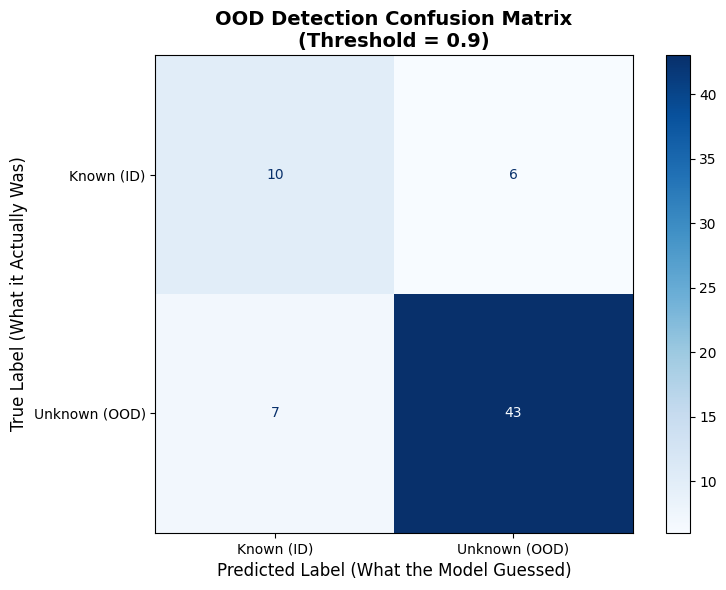

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model


model_filepath = '/kaggle/working/model_b_config2_best.keras'
champion_model = load_model(model_filepath)

print("--- Phase 1: Processing OOD Images ---")
ood_images = []

# Process the unseen images we just downloaded
for path in ood_image_paths:
    if os.path.exists(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224]) # Standard resize for MobileNetV2
        img = tf.cast(img, tf.float32) / 255.0  # Normalize
        ood_images.append(img)

ood_images = np.array(ood_images)
print(f"Successfully processed {len(ood_images)} unseen OOD images.")

print("\n--- Phase 2: Running Predictions ---")
# Grab 1 batch of KNOWN images from your validation dataset to act as "In-Distribution"
for id_images, _ in val_dataset.take(1):
    break

# Ask the model to predict on both groups
preds_id = champion_model.predict(id_images, verbose=0)
preds_ood = champion_model.predict(ood_images, verbose=0)

# Get the MAXIMUM confidence score (probability) for each image
confidence_id = np.max(preds_id, axis=1)
confidence_ood = np.max(preds_ood, axis=1)

print("\n--- Phase 3: Applying Threshold & Metrics ---")
# Define our baseline threshold
THRESHOLD = 0.90

# Flag as 0 (Known/ID) if confidence >= Threshold
# Flag as 1 (Unknown/OOD) if confidence < Threshold
pred_flags_id = (confidence_id < THRESHOLD).astype(int)
pred_flags_ood = (confidence_ood < THRESHOLD).astype(int)

# Create the "Ground Truth" answers (Known is all 0s, Unknown is all 1s)
true_flags_id = np.zeros(len(confidence_id))
true_flags_ood = np.ones(len(confidence_ood))

# Combine them for the final evaluation
y_true = np.concatenate([true_flags_id, true_flags_ood])
y_pred = np.concatenate([pred_flags_id, pred_flags_ood])

# Calculate Precision and Recall
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)

print("-" * 50)
print(f"🎯 OOD DETECTION RESULTS (Threshold = {THRESHOLD}) 🎯")
print("-" * 50)
print(f"Precision: {precision:.2f} (When it flagged 'Unknown', it was right {precision*100:.0f}% of the time)")
print(f"Recall   : {recall:.2f} (It successfully caught {recall*100:.0f}% of all actual unseen objects)")

print("\n--- Phase 4: Generating Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
labels = ['Known (ID)', 'Unknown (OOD)']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title(f'OOD Detection Confusion Matrix\n(Threshold = {THRESHOLD})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label (What the Model Guessed)', fontsize=12)
plt.ylabel('True Label (What it Actually Was)', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

print("-" * 50)
print("🔍 THRESHOLD SWEEPER: Finding the best OOD balance")
print("-" * 50)

# We will test everything from a loose 0.60 to an ultra-strict 0.95
thresholds_to_test = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

for t in thresholds_to_test:
    # Apply the current threshold
    temp_pred_id = (confidence_id < t).astype(int)
    temp_pred_ood = (confidence_ood < t).astype(int)
    
    # Combine predictions
    temp_y_pred = np.concatenate([temp_pred_id, temp_pred_ood])
    
    # Calculate metrics
    prec = precision_score(y_true, temp_y_pred, zero_division=0)
    rec = recall_score(y_true, temp_y_pred, zero_division=0)
    
    print(f"Threshold: {t:.2f}  -->  Precision: {prec:.2f}  |  Recall: {rec:.2f}")

print("-" * 50)

--------------------------------------------------
🔍 THRESHOLD SWEEPER: Finding the best OOD balance
--------------------------------------------------
Threshold: 0.60  -->  Precision: 0.94  |  Recall: 0.34
Threshold: 0.65  -->  Precision: 0.88  |  Recall: 0.42
Threshold: 0.70  -->  Precision: 0.89  |  Recall: 0.48
Threshold: 0.75  -->  Precision: 0.88  |  Recall: 0.56
Threshold: 0.80  -->  Precision: 0.89  |  Recall: 0.66
Threshold: 0.85  -->  Precision: 0.88  |  Recall: 0.76
Threshold: 0.90  -->  Precision: 0.88  |  Recall: 0.86
Threshold: 0.95  -->  Precision: 0.87  |  Recall: 0.92
--------------------------------------------------


# Evaluation

🏆 GENERATING SECTION 4.5 EVALUATION REPORT FOR 5 MODELS 🏆

Extracting validation data...

🚀 EVALUATING: Model A - Config 1


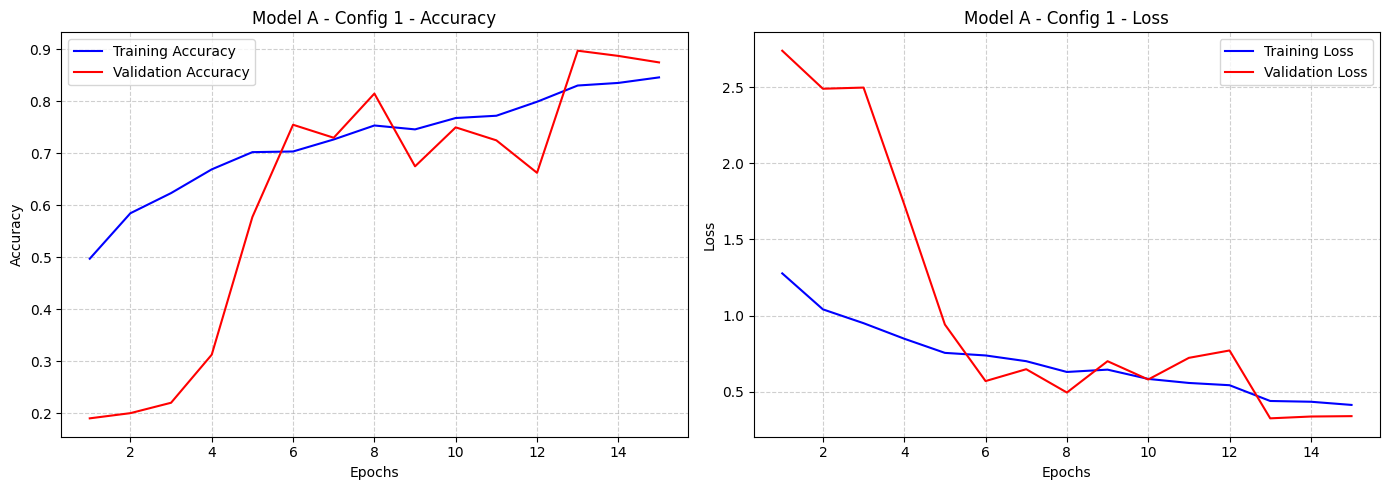

Loading weights from /kaggle/working/model_a_config1_best.keras...

📊 CLASSIFICATION METRICS:
              precision    recall  f1-score   support

     Class 0      0.896     0.932     0.914        74
     Class 1      0.986     0.901     0.942        81
     Class 2      0.732     0.959     0.830        74
     Class 3      0.837     0.867     0.852        83
     Class 4      0.879     0.659     0.753        88

    accuracy                          0.858       400
   macro avg      0.866     0.864     0.858       400
weighted avg      0.868     0.858     0.856       400


🗺️ CONFUSION MATRIX HEATMAP:


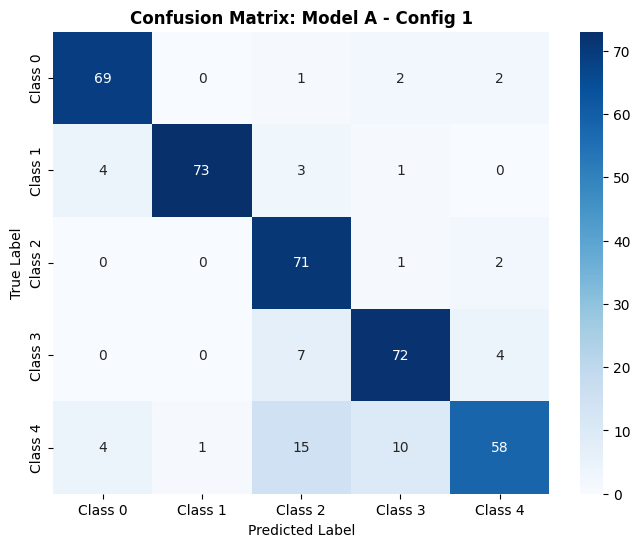





🚀 EVALUATING: Model A - Config 2


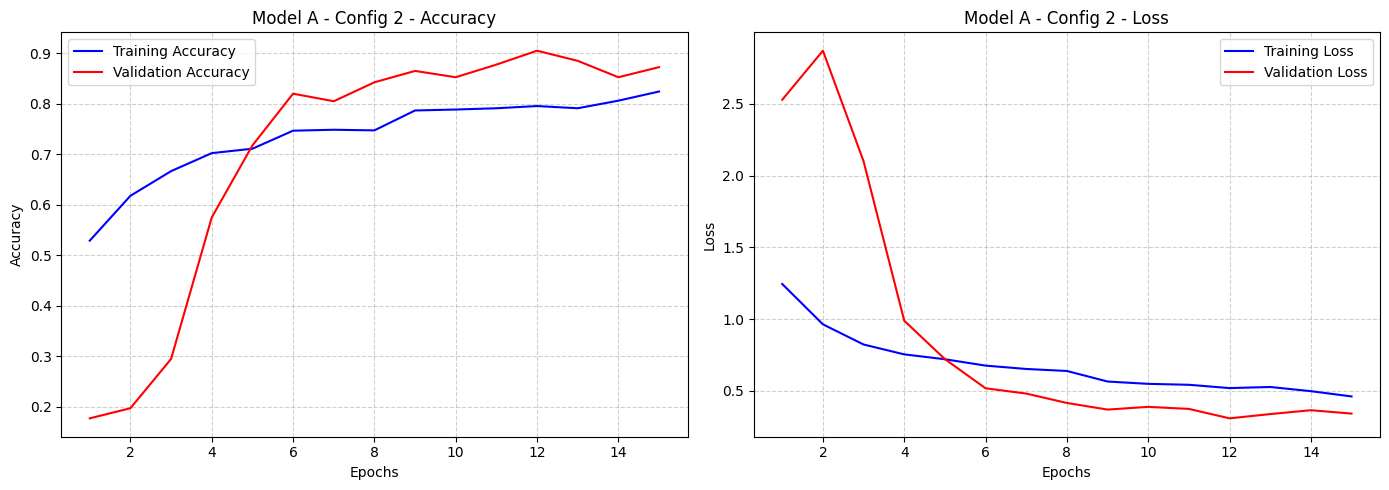

Loading weights from /kaggle/working/model_a_config2_best.keras...

📊 CLASSIFICATION METRICS:
              precision    recall  f1-score   support

     Class 0      0.948     0.986     0.967        74
     Class 1      0.929     0.975     0.952        81
     Class 2      0.963     0.703     0.812        74
     Class 3      0.810     0.819     0.814        83
     Class 4      0.720     0.818     0.766        88

    accuracy                          0.860       400
   macro avg      0.874     0.860     0.862       400
weighted avg      0.868     0.860     0.859       400


🗺️ CONFUSION MATRIX HEATMAP:


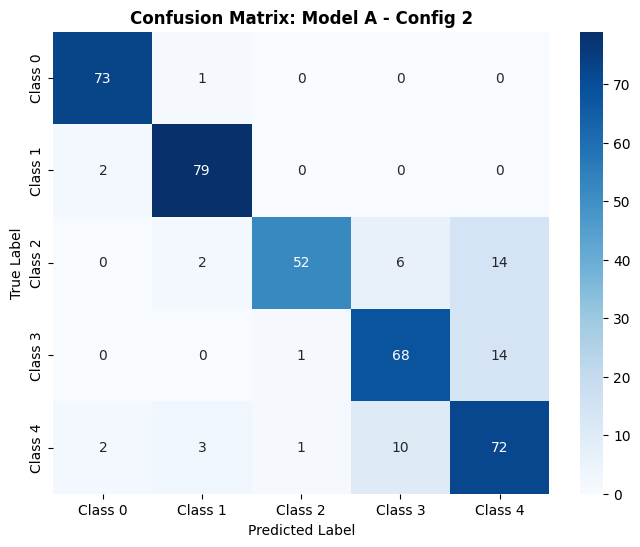





🚀 EVALUATING: Model B - Config 1


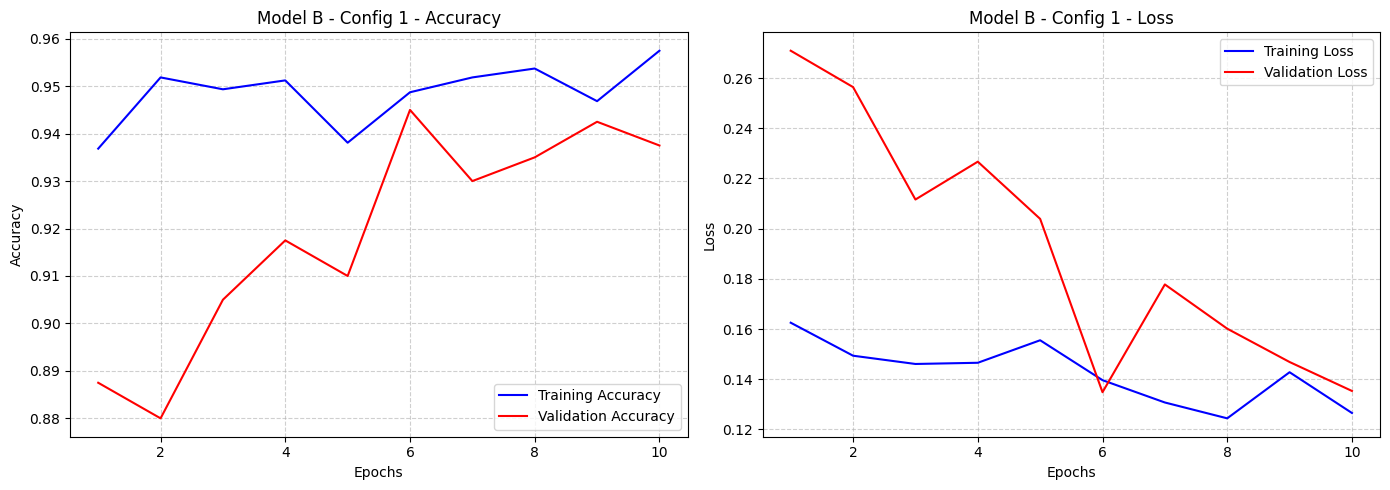

Loading weights from /kaggle/working/model_b_config1_best.keras...

📊 CLASSIFICATION METRICS:
              precision    recall  f1-score   support

     Class 0      0.959     0.959     0.959        74
     Class 1      0.988     1.000     0.994        81
     Class 2      0.818     0.851     0.834        74
     Class 3      0.889     0.867     0.878        83
     Class 4      0.826     0.807     0.816        88

    accuracy                          0.895       400
   macro avg      0.896     0.897     0.896       400
weighted avg      0.895     0.895     0.895       400


🗺️ CONFUSION MATRIX HEATMAP:


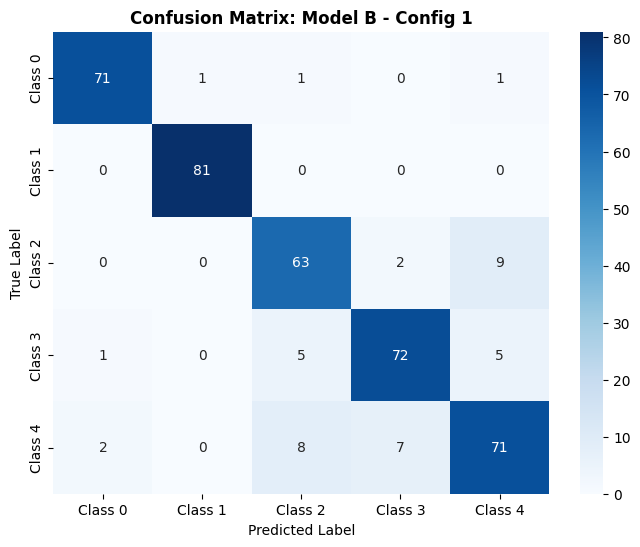





🚀 EVALUATING: Model B - Config 2


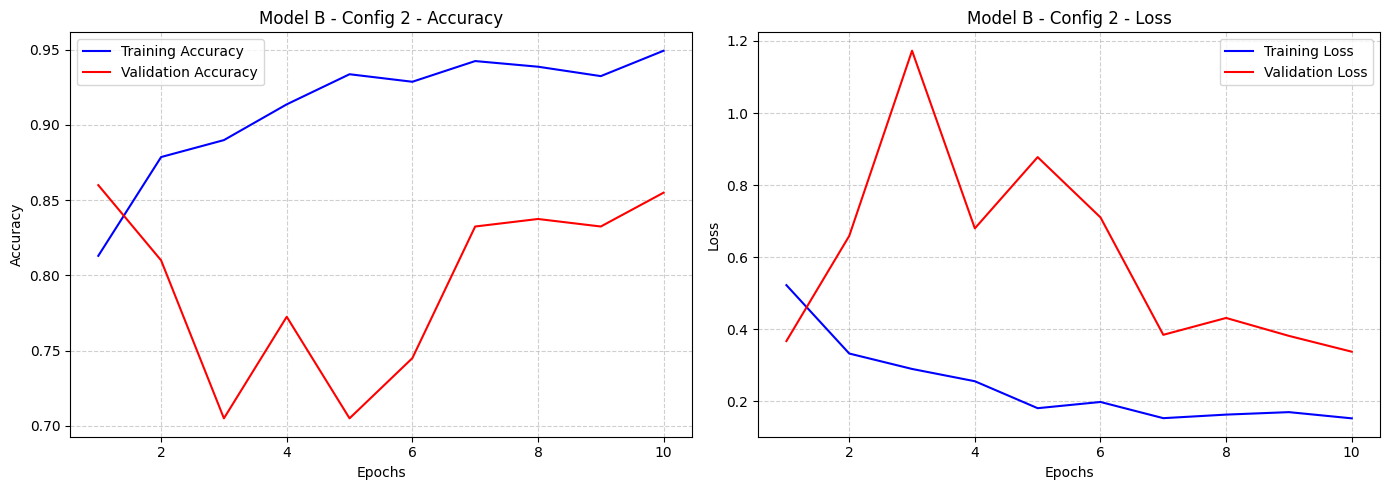

Loading weights from /kaggle/working/model_b_config2_best.keras...

📊 CLASSIFICATION METRICS:
              precision    recall  f1-score   support

     Class 0      0.984     0.851     0.913        74
     Class 1      0.987     0.963     0.975        81
     Class 2      0.843     0.797     0.819        74
     Class 3      0.638     0.976     0.771        83
     Class 4      0.883     0.602     0.716        88

    accuracy                          0.835       400
   macro avg      0.867     0.838     0.839       400
weighted avg      0.865     0.835     0.836       400


🗺️ CONFUSION MATRIX HEATMAP:


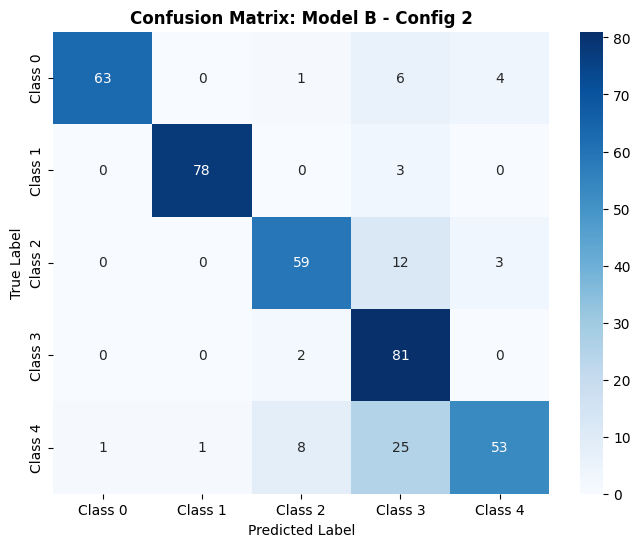





🚀 EVALUATING: Model B - Config 3


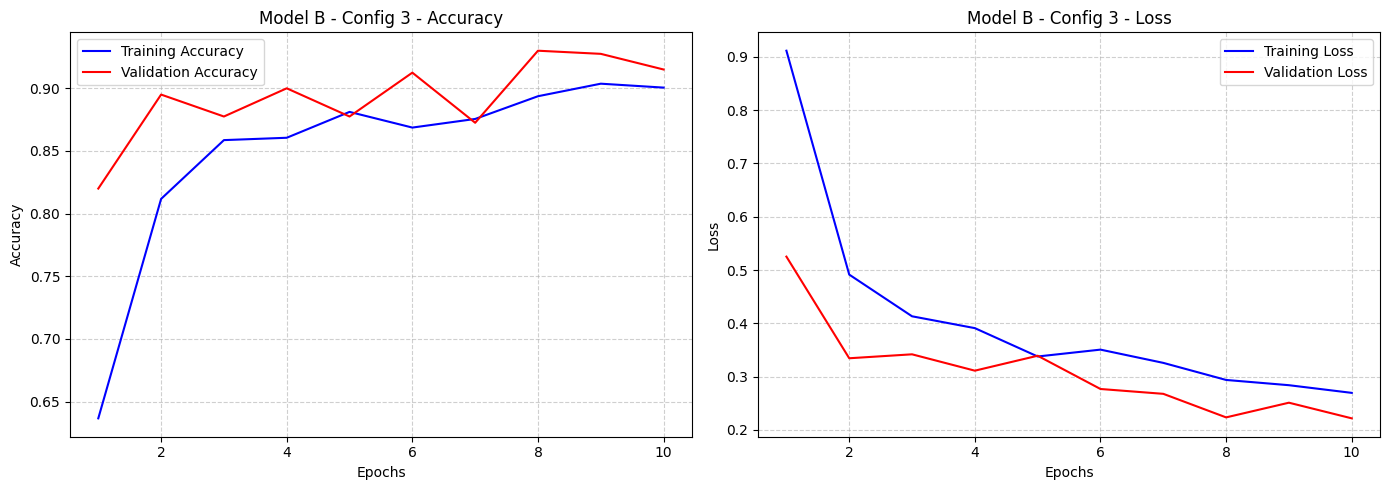

Loading weights from /kaggle/working/model_b_config3_best.keras...

📊 CLASSIFICATION METRICS:
              precision    recall  f1-score   support

     Class 0      1.000     0.986     0.993        74
     Class 1      1.000     1.000     1.000        81
     Class 2      0.922     0.959     0.940        74
     Class 3      0.828     0.988     0.901        83
     Class 4      0.971     0.773     0.861        88

    accuracy                          0.938       400
   macro avg      0.944     0.941     0.939       400
weighted avg      0.944     0.938     0.937       400


🗺️ CONFUSION MATRIX HEATMAP:


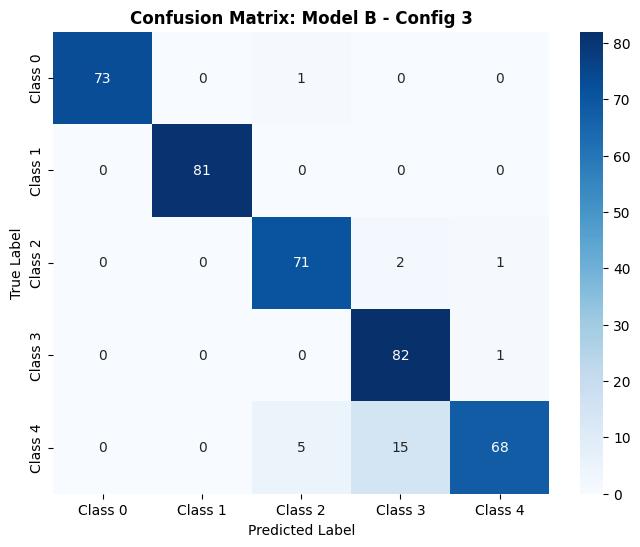

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

print("🏆 GENERATING SECTION 4.5 EVALUATION REPORT FOR 5 MODELS 🏆\n")

# ==========================================
# 1. SETUP: YOUR 5 MODELS
# ==========================================
# CHANGE THE "history" VARIABLES BELOW TO MATCH WHAT YOU NAMED THEM DURING TRAINING!
# If you don't have the history variables anymore, change them to None.
models_to_evaluate = [
    {
        "name": "Model A - Config 1",
        "path": "/kaggle/working/model_a_config1_best.keras",
        "history": history_1  # <--- CHANGE THIS to your actual history variable (or None)
    },
    {
        "name": "Model A - Config 2",
        "path": "/kaggle/working/model_a_config2_best.keras",
        "history": history_2  # <--- CHANGE THIS to your actual history variable (or None)
    },
    {
        "name": "Model B - Config 1",
        "path": "/kaggle/working/model_b_config1_best.keras",
        "history": history_full_tune  # <--- CHANGE THIS to your actual history variable (or None)
    },
    {
        "name": "Model B - Config 2",
        "path": "/kaggle/working/model_b_config2_best.keras",
        "history": history_partial_tune  # <--- CHANGE THIS to your actual history variable (or None)
    },
    {
        "name": "Model B - Config 3",
        "path": "/kaggle/working/model_b_config3_best.keras",
        "history": history_feature_extraction  # <--- CHANGE THIS to your actual history variable (or None)
    }
]

# Extract validation data (Assuming val_dataset is still in memory)
print("Extracting validation data...")
y_true_val = []
val_images = []
for images, labels in val_dataset:
    val_images.append(images)
    y_true_val.extend(labels.numpy())

val_images = np.concatenate(val_images)
y_true_val = np.array(y_true_val)
class_names = [f"Class {i}" for i in range(5)] # Update if you have actual string names for your classes

# ==========================================
# 2. THE MASTER EVALUATION LOOP
# ==========================================
for config in models_to_evaluate:
    print("\n" + "=" * 60)
    print(f"🚀 EVALUATING: {config['name']}")
    print("=" * 60)
    
    # --- A. Plot Training & Validation Curves (If history exists) ---
    if config['history'] is not None:
        try:
            hist = config['history'].history
            epochs = range(1, len(hist['accuracy']) + 1)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Accuracy Curve
            ax1.plot(epochs, hist['accuracy'], 'b-', label='Training Accuracy')
            ax1.plot(epochs, hist['val_accuracy'], 'r-', label='Validation Accuracy')
            ax1.set_title(f"{config['name']} - Accuracy")
            ax1.set_xlabel('Epochs')
            ax1.set_ylabel('Accuracy')
            ax1.legend()
            ax1.grid(True, linestyle='--', alpha=0.6)
            
            # Loss Curve
            ax2.plot(epochs, hist['loss'], 'b-', label='Training Loss')
            ax2.plot(epochs, hist['val_loss'], 'r-', label='Validation Loss')
            ax2.set_title(f"{config['name']} - Loss")
            ax2.set_xlabel('Epochs')
            ax2.set_ylabel('Loss')
            ax2.legend()
            ax2.grid(True, linestyle='--', alpha=0.6)
            
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"⚠️ Could not plot curves: {e}")
    else:
        print("⚠️ No history variable provided. Skipping learning curves.")

    # --- B. Load Model & Predict ---
    print(f"Loading weights from {config['path']}...")
    try:
        model = load_model(config['path'])
    except Exception as e:
        print(f"❌ FAILED to load model file at {config['path']}. Error: {e}")
        continue # Skip to the next model
        
    preds = model.predict(val_images, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    
    # --- C. Print Metrics (Precision, Recall, F1, Macro, Accuracy) ---
    print("\n📊 CLASSIFICATION METRICS:")
    report = classification_report(y_true_val, y_pred, target_names=class_names, digits=3)
    print(report)
    
    # --- D. Confusion Matrix Heatmap ---
    print("\n🗺️ CONFUSION MATRIX HEATMAP:")
    cm = confusion_matrix(y_true_val, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix: {config['name']}", fontweight='bold')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    print("\n\n")